In [ ]:
%load_ext autoreload
%autoreload 2

import os, random, copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes

from gllvm.simulations import make_sparse, make_mixed, simulate
from gllvm.encoder import Encoder
from gllvm.plots import compare_wz, compare_bias, compare_z

SEED = 425
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device: cuda


## Setup

In [5]:
N_LATENT   = 10
ACTIVE     = 5       # last 5 latent dims are structural zeros in the true model
N_RESPONSE = 100
WZ_SCALE   = 0.3

# True model (sparse)
g0 = make_sparse(n_latent=N_LATENT, poisson=N_RESPONSE,
                 active_latent=ACTIVE, wz_scale=WZ_SCALE)

N_SAMPLES = 2000
y0, z0 = simulate(g0, n_samples=N_SAMPLES, device=device)

print(f"True wz silent cols: {(g0.wz[:, ACTIVE:].abs().sum()==0).item()}")
print(f"y0 range: [{y0.min():.1f}, {y0.max():.1f}]")

True wz silent cols: True
y0 range: [0.0, 462.0]


## Single-run illustration

**Encoder strategy:** train a Gaussian VAE on `log1p(y)` — transforms
Poisson counts to bounded inputs, uses a simple linear reconstruction head,
completely decoupled from the Poisson decoder.  After warmup the encoder is
frozen and passed to both arms.

**Baseline decoder:** frozen enc + `E_q[log p(y|z)]` maximised with `log_prob`
(Poisson gradient = `y − mu`, always bounded).

**ZQE decoder:** same frozen enc + centred objective
`E[log p(y|z_q(y))] − E[log p(yq|z_q(yq))]` also using `log_prob` (not `zq_log`),
which avoids the `y * linpar` blow-up while still giving a valid contrast function.


In [ ]:
def train_log_transform_encoder(y, n_response, n_latent,
                                steps=2000, lr=1e-3, batch_size=512, device=device):
    """
    Gaussian VAE trained on log1p(y).

    Encoder architecture: standard Encoder (MLP → mu, logvar).
    Decoder for warmup: a linear head mapping z → log1p(y) predictions.
    Loss = Gaussian reconstruction on log1p(y) + KL(q||N(0,I)).

    Completely decoupled from the Poisson decoder — no exp(linpar) anywhere.
    """
    y_tr = torch.log1p(y.float()).to(device)
    n = len(y_tr)

    enc = Encoder(input_dim=n_response, latent_dim=n_latent, hidden=64).to(device)
    dec_head = nn.Linear(n_latent, n_response).to(device)   # scratch decoder, only used here
    opt = torch.optim.Adam(list(enc.parameters()) + list(dec_head.parameters()), lr=lr)

    for step in range(steps):
        idx = torch.randint(0, n, (batch_size,), device=device)
        batch = y_tr[idx]

        mu, logvar = enc.forward(batch)
        std = torch.exp(0.5 * logvar)
        z = mu + std * torch.randn_like(std)

        rec  = 0.5 * ((batch - dec_head(z)) ** 2).sum(dim=-1).mean()
        kl   = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=-1).mean()
        loss = rec + kl

        opt.zero_grad(); loss.backward(); opt.step()
        if (step + 1) % 500 == 0:
            print(f"  step {step+1}: rec={rec.item():.3f}  kl={kl.item():.3f}")

    return enc   # dec_head discarded after warmup


def decoder_step(gllvm, encoder, y_batch, opt, centred=False):
    """
    Single decoder update step.

    centred=False → plug-in ELBO: loss = -E_q[log p(y|z)]
    centred=True  → ZQE contrast:  loss = -(E[log p(y|z_q(y))] - E[log p(yq|z_q(yq))])

    Both use log_prob (clamped exp, always finite) rather than zq_log (raw eta*T(y)).
    """
    with torch.no_grad():
        z, _, _ = encoder.sample(y_batch)
        logp_y = gllvm.log_prob(y_batch, z=z).sum(dim=-1).mean()

    if centred:
        with torch.no_grad():
            zq0 = gllvm.sample_z(len(y_batch))
            yq  = gllvm.sample(z=zq0)
            z_q, _, _ = encoder.sample(yq)
        logp_yq = gllvm.log_prob(yq, z=z_q).sum(dim=-1).mean()
        # recompute m1 with grad on gllvm params
        z2, _, _ = encoder.sample(y_batch)
        m1 = gllvm.log_prob(y_batch, z=z2.detach()).sum(dim=-1).mean()
        m2 = gllvm.log_prob(yq,      z=z_q.detach()).sum(dim=-1).mean()
        loss = -(m1 - m2)
    else:
        z2, _, _ = encoder.sample(y_batch)
        loss = -gllvm.log_prob(y_batch, z=z2.detach()).sum(dim=-1).mean()

    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(gllvm.parameters(), max_norm=5.0)
    if not torch.isnan(loss): opt.step()
    return -loss.item()


def fit_decoder(gllvm, encoder, y, epochs=500, batch_size=512, lr=1e-3,
                centred=False, device=device, verbose_every=100):
    gllvm = gllvm.to(device); encoder = encoder.to(device); y = y.to(device)
    for p in encoder.parameters(): p.requires_grad_(False)
    opt = torch.optim.Adam(gllvm.parameters(), lr=lr)
    n = len(y)
    for epoch in range(epochs):
        perm = torch.randperm(n, device=device)
        total = 0.0
        for i in range(0, n, batch_size):
            batch = y[perm[i: i + batch_size]]
            total += decoder_step(gllvm, encoder, batch, opt, centred=centred)
        if (epoch + 1) % verbose_every == 0:
            tag = "ZQE" if centred else "plug-in"
            print(f"  [{tag}] Epoch {epoch+1}: log-prob={total:.3f}")


# ── Shared frozen encoder ──────────────────────────────────────────────────────
print("Training log-transform encoder on real data...")
enc_shared = train_log_transform_encoder(y0, N_RESPONSE, N_LATENT, steps=2000)
for p in enc_shared.parameters(): p.requires_grad_(False)
print("Encoder done.")

# ── Baseline: plug-in ELBO ─────────────────────────────────────────────────────
g_base = make_mixed(n_latent=N_LATENT, poisson=N_RESPONSE, wz_scale=WZ_SCALE).to(device)
print("Fitting baseline (plug-in ELBO)...")
fit_decoder(g_base, enc_shared, y0, epochs=500, lr=1e-3,  centred=False)
fit_decoder(g_base, enc_shared, y0, epochs=500, lr=3e-4, centred=False)
print("Baseline done.")


Encoder warmup done.
Fitting baseline (plug-in ELBO, lr=1e-3)...
  Epoch 50: log-prob=-1210.378
  Epoch 50: log-prob=-1210.378
  Epoch 100: log-prob=-928.387
  Epoch 100: log-prob=-928.387
  Epoch 150: log-prob=-829.050
  Epoch 150: log-prob=-829.050
  Epoch 200: log-prob=-773.465
  Epoch 200: log-prob=-773.465
  Epoch 250: log-prob=-775.020
  Epoch 250: log-prob=-775.020
  Epoch 300: log-prob=-722.289
  Epoch 300: log-prob=-722.289
  Epoch 350: log-prob=-706.793
  Epoch 350: log-prob=-706.793
  Epoch 400: log-prob=-696.733
  Epoch 400: log-prob=-696.733
  Epoch 450: log-prob=-694.358
  Epoch 450: log-prob=-694.358
  Epoch 500: log-prob=-682.184
Fitting baseline (plug-in ELBO, lr=3e-4)...
  Epoch 500: log-prob=-682.184
Fitting baseline (plug-in ELBO, lr=3e-4)...
  Epoch 50: log-prob=-680.086
  Epoch 50: log-prob=-680.086
  Epoch 100: log-prob=-678.478
  Epoch 100: log-prob=-678.478
  Epoch 150: log-prob=-678.927
  Epoch 150: log-prob=-678.927
  Epoch 200: log-prob=-677.751
  Epoch 200:

In [ ]:
# ── ZQE: same frozen encoder, centred decoder ────────────────────────────────
g_zqe = make_mixed(n_latent=N_LATENT, poisson=N_RESPONSE, wz_scale=WZ_SCALE).to(device)
enc_zqe = copy.deepcopy(enc_shared)

print("Fitting ZQE (centred)...")
fit_decoder(g_zqe, enc_zqe, y0, epochs=500, lr=1e-3,  centred=True)
fit_decoder(g_zqe, enc_zqe, y0, epochs=500, lr=3e-4, centred=True)
print("ZQE done.")


Fitting ZQE (lr=1e-3)...
Epoch 1: ELBO=0.00
Epoch 2: ELBO=0.00
Epoch 3: ELBO=0.00
Epoch 4: ELBO=0.00
Epoch 5: ELBO=0.00
Epoch 6: ELBO=0.00
Epoch 7: ELBO=0.00
Epoch 8: ELBO=0.00
Epoch 9: ELBO=0.00
Epoch 10: ELBO=0.00
Epoch 11: ELBO=0.00
Epoch 12: ELBO=0.00
Epoch 13: ELBO=0.00
Epoch 14: ELBO=0.00
Epoch 15: ELBO=0.00
Epoch 16: ELBO=0.00
Epoch 17: ELBO=0.00
Epoch 18: ELBO=0.00
Epoch 19: ELBO=0.00
Epoch 20: ELBO=0.00
Epoch 21: ELBO=0.00
Epoch 22: ELBO=0.00
Epoch 23: ELBO=0.00
Epoch 24: ELBO=0.00
Epoch 23: ELBO=0.00
Epoch 24: ELBO=0.00
Epoch 25: ELBO=0.00
Epoch 26: ELBO=0.00
Epoch 27: ELBO=0.00
Epoch 28: ELBO=0.00
Epoch 29: ELBO=0.00
Epoch 30: ELBO=0.00
Epoch 31: ELBO=0.00
Epoch 32: ELBO=0.00
Epoch 33: ELBO=0.00
Epoch 34: ELBO=0.00
Epoch 35: ELBO=0.00
Epoch 36: ELBO=0.00
Epoch 37: ELBO=0.00
Epoch 38: ELBO=0.00
Epoch 39: ELBO=0.00
Epoch 40: ELBO=0.00
Epoch 41: ELBO=0.00
Epoch 42: ELBO=0.00
Epoch 43: ELBO=0.00
Epoch 44: ELBO=0.00
Epoch 45: ELBO=0.00
Epoch 25: ELBO=0.00
Epoch 26: ELBO=0.00
Epoc

ValueError: Expected parameter rate (Tensor of shape (512, 100)) of distribution PoissonGLM(linpar=tensor([[ -0.5696,  -1.0027,  -2.0450,  ...,  -4.9932,  -1.6329,  -2.1807],
        [ -1.7775,  -0.6568,  -0.7908,  ...,  -0.3344,  -0.9434,   3.4361],
        [ -1.4475,  -0.7979,  -1.5042,  ...,  -2.0959,  -1.4716,   1.0843],
        ...,
        [  2.3652,  -1.1145,  -1.5069,  ...,  -1.6627,  -0.2076,  -0.1872],
        [-11.6803,  -0.0625,  -2.7038,  ..., -16.2531,  -6.2147,  -7.5089],
        [-26.4714,   1.3505,  -7.8546,  ..., -54.3184, -17.4674, -30.6033]],
       device='cuda:0', grad_fn=<IndexBackward0>)) to satisfy the constraint GreaterThanEq(lower_bound=0.0), but found invalid values:
tensor([[5.6574e-01, 3.6688e-01, 1.2938e-01,  ..., 6.7839e-03, 1.9536e-01,
         1.1296e-01],
        [1.6905e-01, 5.1850e-01, 4.5349e-01,  ..., 7.1576e-01, 3.8930e-01,
         3.1065e+01],
        [2.3515e-01, 4.5026e-01, 2.2220e-01,  ..., 1.2296e-01, 2.2957e-01,
         2.9573e+00],
     

Wz error — Baseline (plug-in ELBO): 2.9682
Wz error — ZQE (frozen enc):         15.7918
Ratio: 0.19x

--- Baseline ---


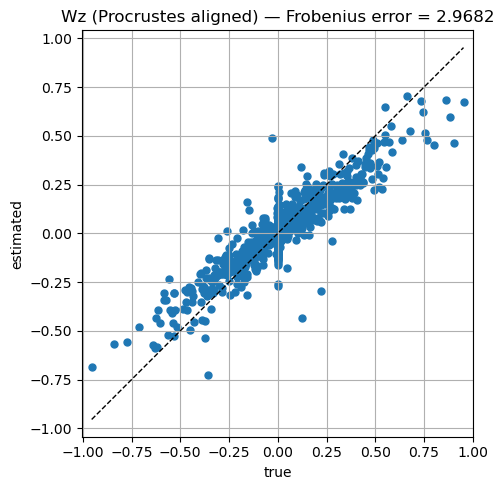

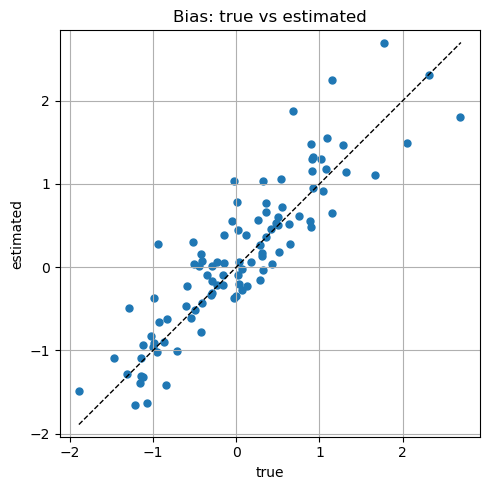


--- ZQE ---


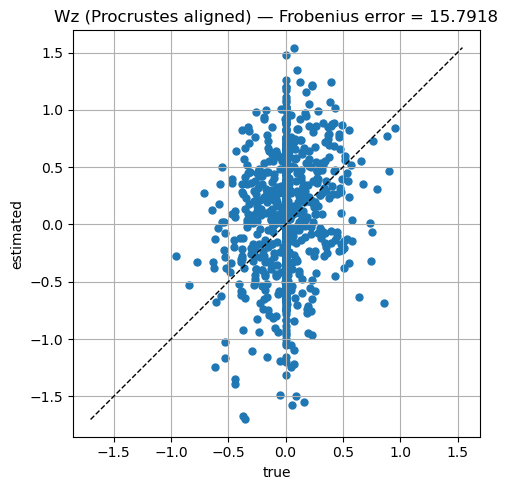

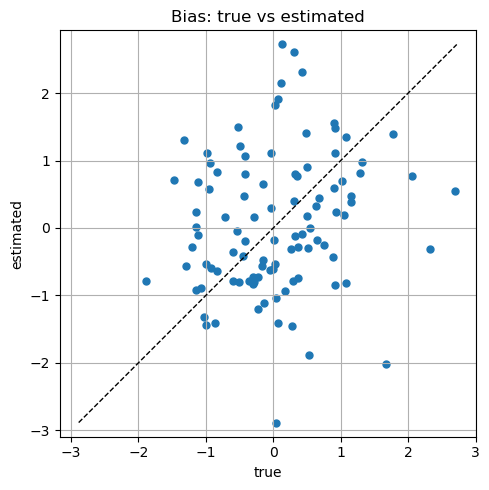

In [8]:
def procrustes_error(W_true, W_est):
    A = W_true.detach().cpu().numpy()
    B = W_est.detach().cpu().numpy()
    R, _ = orthogonal_procrustes(B, A)
    return float(np.linalg.norm(A - B @ R, "fro"))

err_base = procrustes_error(g0.wz, g_base2.wz)
err_zqe  = procrustes_error(g0.wz, g_zqe.wz)
print(f"Wz error — Baseline (plug-in ELBO): {err_base:.4f}")
print(f"Wz error — ZQE (frozen enc):         {err_zqe:.4f}")
print(f"Ratio: {err_base/max(err_zqe,1e-8):.2f}x")

print("\n--- Baseline ---")
compare_wz(g0, g_base2)
compare_bias(g0, g_base2)

print("\n--- ZQE ---")
compare_wz(g0, g_zqe)
compare_bias(g0, g_zqe)


## Asymptotic bias sweep (paper-quality)

VAE/joint error should **plateau** as n grows; ZQE error should **keep shrinking**.

In [ ]:
def run_one(seed, n_samples,
            n_latent=N_LATENT, active=ACTIVE,
            n_response=N_RESPONSE, wz_scale=WZ_SCALE,
            enc_steps=2000, fit_epochs=500, device=device):
    torch.manual_seed(seed); np.random.seed(seed)

    # Ground-truth sparse model + data
    g0_local = make_sparse(n_latent=n_latent, poisson=n_response,
                           active_latent=active, wz_scale=wz_scale)
    y_data, _ = simulate(g0_local, n_samples=n_samples, device=device)

    # Shared frozen log-transform encoder trained on real data
    enc = train_log_transform_encoder(y_data, n_response, n_latent,
                                      steps=enc_steps, device=device)
    for p in enc.parameters(): p.requires_grad_(False)

    # ---- Baseline: frozen enc + plug-in ELBO ----
    g_base = make_mixed(n_latent=n_latent, poisson=n_response, wz_scale=wz_scale).to(device)
    for lr in [1e-3, 3e-4]:
        fit_decoder(g_base, enc, y_data, epochs=fit_epochs, lr=lr,
                    centred=False, device=device, verbose_every=9999)

    # ---- ZQE: frozen enc + centred contrast ----
    g_zqe = make_mixed(n_latent=n_latent, poisson=n_response, wz_scale=wz_scale).to(device)
    enc_z = copy.deepcopy(enc)
    for lr in [1e-3, 3e-4]:
        fit_decoder(g_zqe, enc_z, y_data, epochs=fit_epochs, lr=lr,
                    centred=True, device=device, verbose_every=9999)

    def ferr(W_true, W_est):
        A = W_true.detach().cpu().numpy()
        B = W_est.detach().cpu().numpy()
        R, _ = orthogonal_procrustes(B, A)
        return float(np.linalg.norm(A - B @ R, "fro"))

    return ferr(g0_local.wz, g_base.wz), ferr(g0_local.wz, g_zqe.wz)


N_GRID  = [200, 500, 1000, 2000, 4000]
N_SEEDS = 5   # raise to 20 for paper

results = {n: {"base": [], "zqe": []} for n in N_GRID}

for n in N_GRID:
    for s in range(N_SEEDS):
        eb, ez = run_one(seed=s, n_samples=n)
        results[n]["base"].append(eb)
        results[n]["zqe"].append(ez)
    print(f"n={n:5d}  Base={np.mean(results[n]['base']):.3f}±{np.std(results[n]['base']):.3f}"
          f"  ZQE={np.mean(results[n]['zqe']):.3f}±{np.std(results[n]['zqe']):.3f}")


In [ ]:
ns     = N_GRID
base_m = [np.mean(results[n]["base"]) for n in ns]
base_s = [np.std(results[n]["base"])  for n in ns]
zqe_m  = [np.mean(results[n]["zqe"])  for n in ns]
zqe_s  = [np.std(results[n]["zqe"])   for n in ns]

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(ns, base_m, yerr=base_s, marker="o",
            label="Joint (baseline)", color="tab:red",  capsize=4)
ax.errorbar(ns, zqe_m,  yerr=zqe_s,  marker="s",
            label="ZQE (frozen enc)", color="tab:blue", capsize=4)
ax.set_xlabel("n (sample size)")
ax.set_ylabel("Wz Frobenius error (Procrustes)")
ax.set_title("Exp B — supervised encoder: joint vs ZQE\n"
             f"q={N_LATENT}, active={ACTIVE}, p={N_RESPONSE} Poisson")
ax.set_xscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nRatio Base/ZQE by n:")
for n, bm, zm in zip(ns, base_m, zqe_m):
    print(f"  n={n:5d}  ratio={bm/max(zm,1e-8):.2f}x")